# ESOL: SEG vs TAME vs TAME-Fusion

This notebook compares five runs on the same ESOL split (single-task regression):
1. SEG (Graph + Text, cross-modal MHA)
2. TAME (tri-modal MoE; implemented via TAME)
3. TAME (Stage-1 init): TAME initialized with Stage-1-pretrained Cheb encoder
4. TAME-Fusion (SEG-style fusion + descriptor 2-gate MoE)
5. TAME-Fusion (Stage-1 init): TAME-Fusion initialized with Stage-1-pretrained Cheb encoder

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors

import deepchem as dc

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

print(f'Workspace root: {workspace_root}')
print(f'Device: {device}')

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace root: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float32).reshape(-1)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if int(mask.sum()) == 0:
        return {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_eval': 0}

    yt = y_true[mask]
    yp = y_pred[mask]
    err = yp - yt

    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - np.mean(yt)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'n_eval': int(mask.sum())}

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    n_desc = len(desc_names)
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append(np.full((n_desc,), np.nan, dtype=np.float32))
            continue
        all_desc = Descriptors.CalcMolDescriptors(mol)
        row = []
        for name in desc_names:
            try:
                row.append(float(all_desc.get(name, np.nan)))
            except Exception:
                row.append(np.nan)
        rows.append(np.asarray(row, dtype=np.float32))
    return np.vstack(rows).astype(np.float32), desc_names

def impute_with_train_median(train_X, valid_X, test_X):
    med = np.nanmedian(train_X, axis=0)
    med = np.where(np.isfinite(med), med, 0.0).astype(np.float32)

    def _imp(X):
        X = np.asarray(X, dtype=np.float32)
        mask = ~np.isfinite(X)
        if mask.any():
            X = X.copy()
            X[mask] = np.take(med, np.where(mask)[1])
        return X

    return _imp(train_X), _imp(valid_X), _imp(test_X)

In [3]:
SPLIT_TYPE = 'scaffold'
tasks, datasets, _ = dc.molnet.load_delaney(
    featurizer='ECFP',
    splitter='scaffold' if SPLIT_TYPE == 'scaffold' else 'random',
)
train_dc, valid_dc, test_dc = datasets

NUM_TASKS = int(len(tasks))

train_smiles = list(train_dc.ids)
valid_smiles = list(valid_dc.ids)
test_smiles = list(test_dc.ids)

train_y = np.asarray(train_dc.y, dtype=np.float32).reshape(-1)
valid_y = np.asarray(valid_dc.y, dtype=np.float32).reshape(-1)
test_y = np.asarray(test_dc.y, dtype=np.float32).reshape(-1)

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'solubility_fast_text_embeddings_compact.npz'
if not npz_path.exists():
    raise FileNotFoundError(f'Embedding cache not found: {npz_path}')

seg_cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = train_smiles + valid_smiles + test_smiles
all_emb = torch.from_numpy(seg_cache.get_batch(all_smiles)).float()
n_train = len(train_smiles)
n_valid = len(valid_smiles)
train_emb = all_emb[:n_train]
valid_emb = all_emb[n_train:n_train + n_valid]
test_emb = all_emb[n_train + n_valid:]

d_train, desc_names = rdkit_descriptor_matrix(train_smiles)
d_valid, _ = rdkit_descriptor_matrix(valid_smiles)
d_test, _ = rdkit_descriptor_matrix(test_smiles)
d_train, d_valid, d_test = impute_with_train_median(d_train, d_valid, d_test)

print(f'ESOL tasks: {NUM_TASKS}')
print(f'Split: {SPLIT_TYPE} | Sizes -> train={len(train_smiles)}, val={len(valid_smiles)}, test={len(test_smiles)}')
print(f'Text embedding dim: {all_emb.shape[1]} | Descriptor dim: {d_train.shape[1]}')

Loading embeddings from solubility_fast_text_embeddings_compact.npz...
  Loaded 1128 entries, dim=3072
  Memory mode: mapped
ESOL tasks: 1
Split: scaffold | Sizes -> train=902, val=113, test=113
Text embedding dim: 3072 | Descriptor dim: 217


In [4]:
SEG_FIT_KWARGS = {
    'hidden_channels': 64,
    'K': 3,
    'num_layers': 2,
    'pool': 'sum',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'text_proj_init': 'xavier',
    'text_proj_init_gain': 0.1,
    'freeze_text_proj': False,
    'dropout': 0.3,
    'fusion_dropout': 0.3,
    'head_dropout': 0.3,
    'head_type': 'mlp',
    'head_hidden_dim': 32,
    'learning_rate': 5e-4,
    'weight_decay': 1e-2,
    'batch_size': 32,
    'num_epochs': 200,
    'patience': 30,
    'scheduler': 'plateau',
    'scheduler_patience': 5,
    'scheduler_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': None,
}

# TAME = tri-modal TAME-style MoE (Graph + Text + Descriptor)
TAME_FIT_KWARGS = {
    'hidden_channels': 64,
    'K': 3,
    'num_layers': 2,
    'pool': 'sum',
    'set2set_processing_steps': 6,
    'fusion_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 5e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 15,
}

# TAME-Fusion = SEG-style graph+text fusion + 2-gate MoE with descriptors
TAME_FUSION_FIT_KWARGS = {
    'hidden_channels': 64,
    'K': 3,
    'num_layers': 2,
    'pool': 'sum',
    'set2set_processing_steps': 6,
    'fusion': 'cross_mha',
    'fusion_dim': 64,
    'fusion_n_heads': 8,
    'fusion_dropout': 0.30,
    'moe_hidden_dim': 64,
    'projection_dropout': 0.30,
    'router_dropout': 0.35,
    'head_hidden_dim': 64,
    'head_dropout': 0.30,
    'learning_rate': 5e-4,
    'weight_decay': 7e-2,
    'gate_balance_weight': 0.005,
    'desc_modality_dropout': 0.25,
    'descriptor_winsorize_lower_q': 0.01,
    'descriptor_winsorize_upper_q': 0.99,
    'descriptor_standardize': True,
    'batch_size': 64,
    'num_epochs': 120,
    'patience': 15,
}

# Choose which pretraining stage should initialize the encoder.
# Supported: 'stage1_node' or 'stage2_descriptor'.
PRETRAIN_INIT_STAGE = 'stage2_descriptor'

def make_seg_config(text_embedding_dim):
    return SEGPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=SEG_FIT_KWARGS['hidden_channels'],
        K=SEG_FIT_KWARGS['K'],
        num_layers=SEG_FIT_KWARGS['num_layers'],
        dropout=SEG_FIT_KWARGS['dropout'],
        pool=SEG_FIT_KWARGS['pool'],
        set2set_processing_steps=SEG_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        text_projection_dim=SEG_FIT_KWARGS['fusion_dim'],
        text_proj_init=SEG_FIT_KWARGS['text_proj_init'],
        text_proj_init_gain=SEG_FIT_KWARGS['text_proj_init_gain'],
        freeze_text_proj=SEG_FIT_KWARGS['freeze_text_proj'],
        fusion=SEG_FIT_KWARGS['fusion'],
        fusion_dim=SEG_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=SEG_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=SEG_FIT_KWARGS['fusion_dropout'],
        head_type=SEG_FIT_KWARGS['head_type'],
        head_hidden_dim=SEG_FIT_KWARGS['head_hidden_dim'],
        head_dropout=SEG_FIT_KWARGS['head_dropout'],
        add_hydrogens=False,
    )

def make_tame_config(text_embedding_dim):
    return TAMEPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FIT_KWARGS['hidden_channels'],
        K=TAME_FIT_KWARGS['K'],
        num_layers=TAME_FIT_KWARGS['num_layers'],
        pool=TAME_FIT_KWARGS['pool'],
        text_embedding_dim=int(text_embedding_dim),
        fusion_hidden_dim=TAME_FIT_KWARGS['fusion_hidden_dim'],
        projection_dropout=TAME_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def make_tame_fusion_config(text_embedding_dim):
    return TAMEFusionPredictorConfig(
        task='regression',
        num_tasks=NUM_TASKS,
        hidden_channels=TAME_FUSION_FIT_KWARGS['hidden_channels'],
        K=TAME_FUSION_FIT_KWARGS['K'],
        num_layers=TAME_FUSION_FIT_KWARGS['num_layers'],
        pool=TAME_FUSION_FIT_KWARGS['pool'],
        set2set_processing_steps=TAME_FUSION_FIT_KWARGS['set2set_processing_steps'],
        text_embedding_dim=int(text_embedding_dim),
        fusion=TAME_FUSION_FIT_KWARGS['fusion'],
        fusion_dim=TAME_FUSION_FIT_KWARGS['fusion_dim'],
        fusion_n_heads=TAME_FUSION_FIT_KWARGS['fusion_n_heads'],
        fusion_dropout=TAME_FUSION_FIT_KWARGS['fusion_dropout'],
        moe_hidden_dim=TAME_FUSION_FIT_KWARGS['moe_hidden_dim'],
        projection_dropout=TAME_FUSION_FIT_KWARGS['projection_dropout'],
        router_dropout=TAME_FUSION_FIT_KWARGS['router_dropout'],
        head_hidden_dim=TAME_FUSION_FIT_KWARGS['head_hidden_dim'],
        head_dropout=TAME_FUSION_FIT_KWARGS['head_dropout'],
        gate_balance_weight=TAME_FUSION_FIT_KWARGS['gate_balance_weight'],
        desc_modality_dropout=TAME_FUSION_FIT_KWARGS['desc_modality_dropout'],
        descriptor_winsorize_lower_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_lower_q'],
        descriptor_winsorize_upper_q=TAME_FUSION_FIT_KWARGS['descriptor_winsorize_upper_q'],
        descriptor_standardize=TAME_FUSION_FIT_KWARGS['descriptor_standardize'],
        add_hydrogens=False,
    )

def resolve_pretrain_checkpoint(pretrain_stage=PRETRAIN_INIT_STAGE):
    stage_cfg = {
        'stage1_node': {
            'alias': 'cheb_foundation_pretrain_stage1.pt',
            'pattern_prefix': 'cheb_foundation_stage1',
        },
        'stage2_descriptor': {
            'alias': 'cheb_foundation_pretrain.pt',
            'pattern_prefix': 'cheb_foundation_2stage',
        },
        'stage1_stage2': {
            'alias': 'cheb_foundation_pretrain.pt',
            'pattern_prefix': 'cheb_foundation',
        },
    }
    if pretrain_stage not in stage_cfg:
        raise ValueError(
            f"Unsupported PRETRAIN_INIT_STAGE={pretrain_stage!r}. "
            "Use 'stage1_node' or 'stage2_descriptor'."
        )

    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    if not ckpt_dir.exists():
        raise FileNotFoundError(f'Checkpoint directory not found: {ckpt_dir}')

    alias = ckpt_dir / stage_cfg[pretrain_stage]['alias']
    pattern_prefix = stage_cfg[pretrain_stage]['pattern_prefix']
    pattern = (
        f"{pattern_prefix}__h{TAME_FIT_KWARGS['hidden_channels']}__"
        f"L{TAME_FIT_KWARGS['num_layers']}__"
        f"K{TAME_FIT_KWARGS['K']}__*.pt"
    )

    candidates = sorted(
        [p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if candidates:
        return candidates[0]
    if alias.exists():
        return alias
    raise FileNotFoundError(
        f"No checkpoint found for stage={pretrain_stage!r}. "
        f"Tried pattern={pattern!r} and alias={alias.name!r}."
    )

def load_pretrained_encoder_state(ckpt_path, expected_stage=PRETRAIN_INIT_STAGE):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if not isinstance(payload, dict):
        raise RuntimeError('Invalid checkpoint payload format.')

    stage = payload.get('pretraining_stage', None)
    if stage != expected_stage:
        raise RuntimeError(
            f"Expected checkpoint with pretraining_stage={expected_stage!r}, got {stage!r}"
        )

    model_state = payload.get('model_state_dict', {})
    enc_state = {k.replace('encoder.', '', 1): v for k, v in model_state.items() if k.startswith('encoder.')}
    if not enc_state:
        raise RuntimeError('Checkpoint does not contain encoder.* weights.')

    print(f'Loaded {expected_stage} encoder state from: {Path(ckpt_path).resolve()}')
    return enc_state

In [5]:
seg = SEGPredictor(config=make_seg_config(text_embedding_dim=all_emb.shape[1]), device=str(device))
seg_hist = seg.fit(
    smiles_list=train_smiles,
    labels=train_y.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y.tolist(),
    text_embeddings=train_emb,
    val_text_embeddings=valid_emb,
    num_epochs=SEG_FIT_KWARGS['num_epochs'],
    batch_size=SEG_FIT_KWARGS['batch_size'],
    learning_rate=SEG_FIT_KWARGS['learning_rate'],
    weight_decay=SEG_FIT_KWARGS['weight_decay'],
    patience=SEG_FIT_KWARGS['patience'],
    scheduler=SEG_FIT_KWARGS['scheduler'],
    scheduler_patience=SEG_FIT_KWARGS['scheduler_patience'],
    scheduler_factor=SEG_FIT_KWARGS['scheduler_factor'],
    min_lr=SEG_FIT_KWARGS['min_lr'],
    grad_clip=SEG_FIT_KWARGS['grad_clip'],
    seed=seed,
    verbose=True,
)

seg_best_val = float(np.min(seg_hist['val_loss']))
seg_test_pred = np.asarray(seg.predict_batch(test_smiles, text_embeddings=test_emb), dtype=np.float32).reshape(-1)
seg_metrics = regression_metrics(test_y, seg_test_pred)

print('SEG metrics:', seg_metrics)

Pre-computing molecular graphs for 902 molecules...
Pre-computed 902/902 valid graphs
Pre-computing molecular graphs for 113 molecules...
Pre-computed 113/113 valid graphs
Training SEGPredictor on 902 molecules...
Task: regression
Validation set: 113 molecules
Fusion method: cross_mha
LR scheduler: plateau
Epoch 001 | Train Loss: 0.9248 | Val RMSE: 0.7423 | LR: 5.00e-04
Epoch 005 | Train Loss: 0.2533 | Val RMSE: 0.4976 | LR: 5.00e-04
Epoch 010 | Train Loss: 0.1682 | Val RMSE: 0.4718 | LR: 5.00e-04
Epoch 015 | Train Loss: 0.1342 | Val RMSE: 0.4772 | LR: 5.00e-04
Epoch 020 | Train Loss: 0.1173 | Val RMSE: 0.4703 | LR: 5.00e-04
Epoch 025 | Train Loss: 0.1184 | Val RMSE: 0.4606 | LR: 2.50e-04
Epoch 030 | Train Loss: 0.0943 | Val RMSE: 0.4392 | LR: 1.25e-04
Epoch 035 | Train Loss: 0.0885 | Val RMSE: 0.4396 | LR: 1.25e-04
Epoch 040 | Train Loss: 0.0878 | Val RMSE: 0.4387 | LR: 1.25e-04
Epoch 045 | Train Loss: 0.0815 | Val RMSE: 0.4315 | LR: 1.25e-04
Epoch 050 | Train Loss: 0.0914 | Val RMSE:

In [6]:
text_dim = int(all_emb.shape[1])
train_text = np.asarray(train_emb, dtype=np.float32)
valid_text = np.asarray(valid_emb, dtype=np.float32)
test_text = np.asarray(test_emb, dtype=np.float32)

# ------------------------------
# TAME (TAME-style tri-modal)
# ------------------------------
tame_config = make_tame_config(text_dim)
tame_model = TAMEPredictor(tame_config, device=str(device))
tame_hist = tame_model.fit(
    smiles_list=train_smiles,
    labels=train_y.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y.tolist(),
    text_embeddings=train_text,
    val_text_embeddings=valid_text,
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FIT_KWARGS['weight_decay'],
    patience=TAME_FIT_KWARGS['patience'],
    verbose=True,
    seed=seed,
 )

tame_pred = np.asarray(
    tame_model.predict_batch(
        test_smiles,
        text_embeddings=test_text,
        descriptor_features=d_test,
        batch_size=TAME_FIT_KWARGS['batch_size'],
    ),
    dtype=np.float32,
).reshape(-1)
tame_metrics = regression_metrics(test_y, tame_pred)
tame_metrics['model'] = 'TAME_BASELINE'

pretrain_ckpt = resolve_pretrain_checkpoint(PRETRAIN_INIT_STAGE)
pretrained_encoder = load_pretrained_encoder_state(
    pretrain_ckpt,
    expected_stage=PRETRAIN_INIT_STAGE,
)
pretrain_stage_tag = PRETRAIN_INIT_STAGE.replace('_', '-')

tame_init_config = make_tame_config(text_dim)
tame_init_model = TAMEPredictor(tame_init_config, device=str(device))
tame_init_hist = tame_init_model.fit(
    smiles_list=train_smiles,
    labels=train_y.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y.tolist(),
    text_embeddings=train_text,
    val_text_embeddings=valid_text,
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FIT_KWARGS['weight_decay'],
    patience=TAME_FIT_KWARGS['patience'],
    verbose=True,
    seed=seed,
    init_encoder_state=pretrained_encoder,
 )

tame_init_pred = np.asarray(
    tame_init_model.predict_batch(
        test_smiles,
        text_embeddings=test_text,
        descriptor_features=d_test,
        batch_size=TAME_FIT_KWARGS['batch_size'],
    ),
    dtype=np.float32,
).reshape(-1)
tame_init_metrics = regression_metrics(test_y, tame_init_pred)
tame_init_metrics['model'] = f"TAME_{pretrain_stage_tag.upper()}_INIT"

# ------------------------------
# TAME-Fusion (SEG fusion + 2-gate descriptor MoE)
# ------------------------------
tame_fusion_config = make_tame_fusion_config(text_dim)
tame_fusion_model = TAMEFusionPredictor(tame_fusion_config, device=str(device))
tame_fusion_hist = tame_fusion_model.fit(
    smiles_list=train_smiles,
    labels=train_y.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y.tolist(),
    text_embeddings=train_text,
    val_text_embeddings=valid_text,
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FUSION_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FUSION_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FUSION_FIT_KWARGS['weight_decay'],
    patience=TAME_FUSION_FIT_KWARGS['patience'],
    verbose=True,
    seed=seed,
 )

tame_fusion_pred = np.asarray(
    tame_fusion_model.predict_batch(
        test_smiles,
        text_embeddings=test_text,
        descriptor_features=d_test,
        batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
    ),
    dtype=np.float32,
).reshape(-1)
tame_fusion_metrics = regression_metrics(test_y, tame_fusion_pred)
tame_fusion_metrics['model'] = 'TAME_FUSION_BASELINE'

tame_fusion_init_config = make_tame_fusion_config(text_dim)
tame_fusion_init_model = TAMEFusionPredictor(tame_fusion_init_config, device=str(device))
tame_fusion_init_hist = tame_fusion_init_model.fit(
    smiles_list=train_smiles,
    labels=train_y.tolist(),
    val_smiles=valid_smiles,
    val_labels=valid_y.tolist(),
    text_embeddings=train_text,
    val_text_embeddings=valid_text,
    descriptor_features=d_train,
    val_descriptor_features=d_valid,
    num_epochs=TAME_FUSION_FIT_KWARGS['num_epochs'],
    batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
    learning_rate=TAME_FUSION_FIT_KWARGS['learning_rate'],
    weight_decay=TAME_FUSION_FIT_KWARGS['weight_decay'],
    patience=TAME_FUSION_FIT_KWARGS['patience'],
    verbose=True,
    seed=seed,
    init_encoder_state=pretrained_encoder,
 )

tame_fusion_init_pred = np.asarray(
    tame_fusion_init_model.predict_batch(
        test_smiles,
        text_embeddings=test_text,
        descriptor_features=d_test,
        batch_size=TAME_FUSION_FIT_KWARGS['batch_size'],
    ),
    dtype=np.float32,
).reshape(-1)
tame_fusion_init_metrics = regression_metrics(test_y, tame_fusion_init_pred)
tame_fusion_init_metrics['model'] = f"TAME_FUSION_{pretrain_stage_tag.upper()}_INIT"

seg_metrics = dict(seg_metrics)
seg_metrics['model'] = 'SEG'

histories = {
    'SEG': seg_hist,
    'TAME': tame_hist,
    f'TAME-{pretrain_stage_tag}-Init': tame_init_hist,
    'TAME-Fusion': tame_fusion_hist,
    f'TAME-Fusion-{pretrain_stage_tag}-Init': tame_fusion_init_hist,
}

metrics_df = pd.DataFrame([
    seg_metrics,
    tame_metrics,
    tame_init_metrics,
    tame_fusion_metrics,
    tame_fusion_init_metrics,
])
metrics_df = metrics_df[['model', 'mae', 'rmse', 'r2', 'n_eval']]
metrics_df

Descriptor preprocessing enabled (winsor q=[0.010, 0.990], standardize=True)
Epoch 001 | train=0.817428 | val=0.562427 | gates G/T/D=0.329/0.340/0.331
Epoch 005 | train=0.142403 | val=0.208137 | gates G/T/D=0.339/0.368/0.293
Epoch 010 | train=0.097413 | val=0.181414 | gates G/T/D=0.339/0.368/0.293
Epoch 015 | train=0.104828 | val=0.171253 | gates G/T/D=0.337/0.364/0.299
Epoch 020 | train=0.078966 | val=0.160399 | gates G/T/D=0.339/0.360/0.301
Epoch 025 | train=0.086045 | val=0.200799 | gates G/T/D=0.335/0.364/0.301
Epoch 030 | train=0.060572 | val=0.157509 | gates G/T/D=0.343/0.364/0.294
Epoch 035 | train=0.058481 | val=0.156158 | gates G/T/D=0.350/0.365/0.285
Early stopping at epoch 36
Loaded stage2_descriptor encoder state from: C:\Users\robsc\Home\Dev\molfusion2\cache\chemeleon_pretraining\cheb_foundation_2stage__h64__L2__K3__pool-set2set__drop-0p2000__head-256__dim-1592__subset-600000.pt
Descriptor preprocessing enabled (winsor q=[0.010, 0.990], standardize=True)
Initialized TAME e

,model,mae,rmse,r2,n_eval
0,SEG,0.354699,0.434363,0.820630,113
1,TAME_BASELINE,0.322862,0.405798,0.843447,113
2,TAME_STAGE2-DESCRIPTOR_INIT,0.343122,0.448561,0.808713,113
3,TAME_FUSION_BASELINE,0.334612,0.403484,0.845227,113
4,TAME_FUSION_STAGE2-DESCRIPTOR_INIT,0.317641,0.399172,0.848517,113


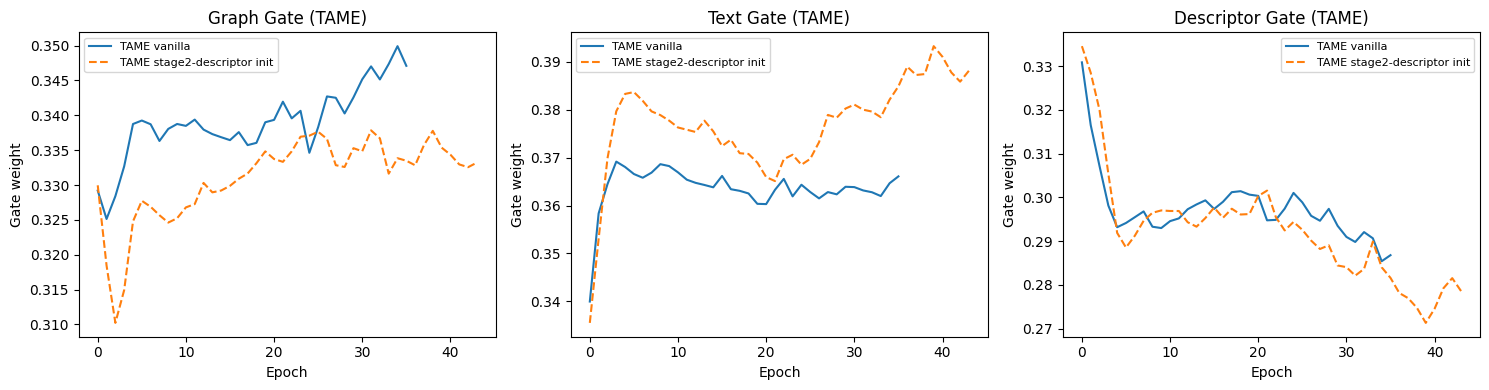

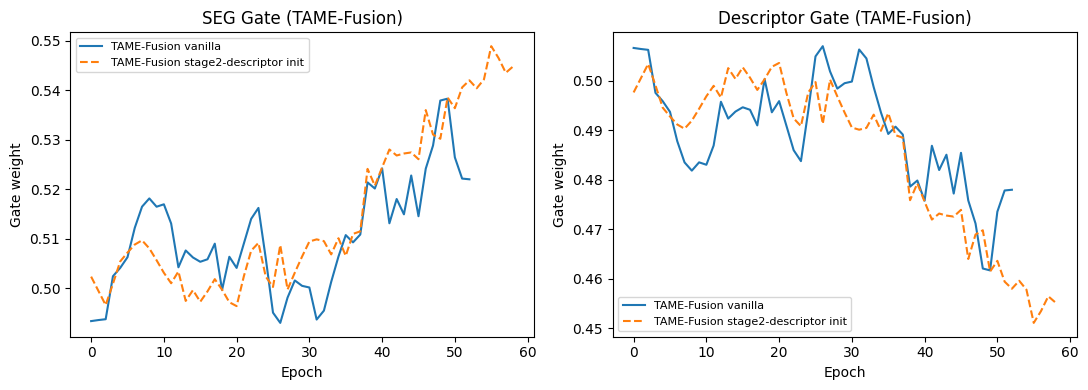

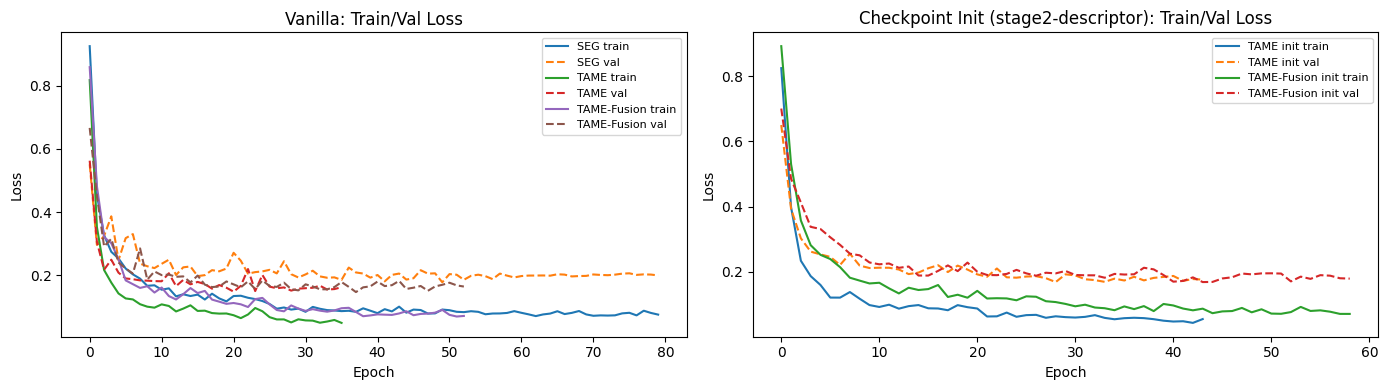

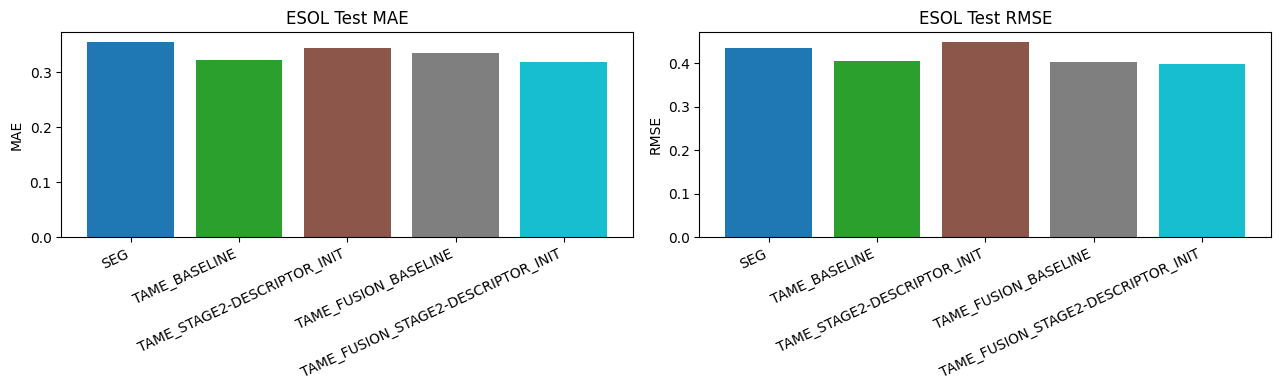

Saved: C:\Users\robsc\Home\Dev\molfusion2\benchmarking\results\esol_seg_tame_tamefusion_init_stage2_descriptor.csv


In [7]:
# 1) Gating evolution: TAME (tri-modal TAME-style)
fig_tame_gate, ax_tame_gate = plt.subplots(1, 3, figsize=(15, 4))
tame_gate_specs = [
    ('graph_gate', 'Graph Gate (TAME)'),
    ('text_gate', 'Text Gate (TAME)'),
    ('desc_gate', 'Descriptor Gate (TAME)'),
]
for i, (gate_key, title) in enumerate(tame_gate_specs):
    if gate_key in tame_hist:
        ax_tame_gate[i].plot(tame_hist[gate_key], label='TAME vanilla')
    if gate_key in tame_init_hist:
        ax_tame_gate[i].plot(tame_init_hist[gate_key], linestyle='--', label=f'TAME {pretrain_stage_tag} init')
    ax_tame_gate[i].set_title(title)
    ax_tame_gate[i].set_xlabel('Epoch')
    ax_tame_gate[i].set_ylabel('Gate weight')
    ax_tame_gate[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2) Gating evolution: TAME-Fusion (2-gate)
fig_tame_fusion_gate, ax_tame_fusion_gate = plt.subplots(1, 2, figsize=(11, 4))
tame_fusion_gate_specs = [
    ('seg_gate', 'SEG Gate (TAME-Fusion)'),
    ('desc_gate', 'Descriptor Gate (TAME-Fusion)'),
]
for i, (gate_key, title) in enumerate(tame_fusion_gate_specs):
    if gate_key in tame_fusion_hist:
        ax_tame_fusion_gate[i].plot(tame_fusion_hist[gate_key], label='TAME-Fusion vanilla')
    if gate_key in tame_fusion_init_hist:
        ax_tame_fusion_gate[i].plot(tame_fusion_init_hist[gate_key], linestyle='--', label=f'TAME-Fusion {pretrain_stage_tag} init')
    ax_tame_fusion_gate[i].set_title(title)
    ax_tame_fusion_gate[i].set_xlabel('Epoch')
    ax_tame_fusion_gate[i].set_ylabel('Gate weight')
    ax_tame_fusion_gate[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

# 3) Train/Val loss curves: vanilla vs checkpoint-init
vanilla_runs = {
    'SEG': seg_hist,
    'TAME': tame_hist,
    'TAME-Fusion': tame_fusion_hist,
}
checkpoint_runs = {
    'TAME': tame_init_hist,
    'TAME-Fusion': tame_fusion_init_hist,
}

fig_loss_cmp, ax_loss_cmp = plt.subplots(1, 2, figsize=(14, 4))
for label, hist in vanilla_runs.items():
    ax_loss_cmp[0].plot(hist.get('train_loss', []), label=f'{label} train')
    ax_loss_cmp[0].plot(hist.get('val_loss', []), linestyle='--', label=f'{label} val')
ax_loss_cmp[0].set_title('Vanilla: Train/Val Loss')
ax_loss_cmp[0].set_xlabel('Epoch')
ax_loss_cmp[0].set_ylabel('Loss')
ax_loss_cmp[0].legend(fontsize=8)

for label, hist in checkpoint_runs.items():
    ax_loss_cmp[1].plot(hist.get('train_loss', []), label=f'{label} init train')
    ax_loss_cmp[1].plot(hist.get('val_loss', []), linestyle='--', label=f'{label} init val')
ax_loss_cmp[1].set_title(f'Checkpoint Init ({pretrain_stage_tag}): Train/Val Loss')
ax_loss_cmp[1].set_xlabel('Epoch')
ax_loss_cmp[1].set_ylabel('Loss')
ax_loss_cmp[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# 4) Metrics comparison bars
labels = metrics_df['model'].tolist()
x = np.arange(len(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(x, metrics_df['mae'].values, color=colors)
ax[0].set_xticks(x, labels, rotation=25, ha='right')
ax[0].set_ylabel('MAE')
ax[0].set_title('ESOL Test MAE')

ax[1].bar(x, metrics_df['rmse'].values, color=colors)
ax[1].set_xticks(x, labels, rotation=25, ha='right')
ax[1].set_ylabel('RMSE')
ax[1].set_title('ESOL Test RMSE')

plt.tight_layout()
plt.show()

results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
out_path = results_dir / f'esol_seg_tame_tamefusion_init_{PRETRAIN_INIT_STAGE}.csv'
metrics_df.to_csv(out_path, index=False)
print(f'Saved: {out_path.resolve()}')